# Projeto 1 - Parte II: Seleção de Modelo

**Disciplina:** MS571  
**Integrantes:** Jhuan Marcos Nunes Solis Silva - 266349; Melissa Schiavon Pastene - 270324; Pedro Rocha Teixeira - 253670

## Objetivo e continuidade da Parte I

Este notebook implementa a **Parte II do Projeto 1** reutilizando a formulação e as decisões metodológicas da Parte I. Em particular, são preservados:

- a arquitetura principal $400\rightarrow25\rightarrow10$;
- a ativação sigmoide em todas as camadas treináveis;
- a codificação *one-hot* das 10 classes;
- a função de custo multiclasse por entropia cruzada logística;
- a regularização L2 sem penalizar os termos de bias;
- a inicialização aleatória reprodutível com `SEED = 2026`;
- o *backpropagation* vetorizado implementado explicitamente;
- o gradiente conjugado por `scipy.optimize.minimize(method="CG")`, permitido pelo enunciado.

A diferença fundamental é que **os pesos aprendidos na Parte I não são reutilizados**. A rede é reinicializada e treinada novamente depois da divisão em treino, validação e teste, evitando vazamento de informação.

A Parte II executa três tarefas pedidas no enunciado:

1. divisão em 60% treino, 20% validação e 20% teste e cálculo dos erros;
2. curva de aprendizado (erro de treino e validação em função de $m$);
3. escolha automática de $\lambda$ pelo conjunto de validação e avaliação final no teste.

> **Como executar:** mantenha `ex3data1.mat` ou o par `imageMNIST.csv`/`labelMNIST.csv` na mesma pasta do notebook (ou em `./dados`). Para um teste técnico rápido, defina `NN_FAST_MODE=1`. A execução final deve ser feita com `FAST_MODE = False`.


## 1. Bibliotecas, reprodutibilidade e configuração

As mesmas bibliotecas numéricas da Parte I são usadas. Não é utilizado nenhum classificador pronto nem biblioteca de redes neurais.


In [1]:
from pathlib import Path
from time import perf_counter
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import minimize
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text

SEED = 2026
FAST_MODE = os.getenv("NN_FAST_MODE", "0") == "1"
np.set_printoptions(precision=6, suppress=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.titlesize": 12})

# Limites de iteração escolhidos para equilibrar convergência e custo computacional.
MAXITER_LAMBDA = 40 if FAST_MODE else 150
MAXITER_CURVA = 35 if FAST_MODE else 100

print("Modo rápido:", FAST_MODE)
print("MAXITER_LAMBDA:", MAXITER_LAMBDA)
print("MAXITER_CURVA:", MAXITER_CURVA)


Modo rápido: False
MAXITER_LAMBDA: 150
MAXITER_CURVA: 100


## 2. Leitura dos dados

A rotina de leitura é a mesma da Parte I. Os rótulos internos $1,\ldots,10$ são preservados; o rótulo `10` representa visualmente o dígito zero. Não é feita padronização adicional dos pixels, mantendo a mesma representação usada anteriormente.


In [2]:
def localizar_arquivo(nomes):
    """Procura nomes exatos ou versões prefixadas nas pastas usuais."""
    pastas = [Path.cwd(), Path.cwd() / "project_sources", Path.cwd() / "dados"]
    for pasta in pastas:
        if not pasta.exists():
            continue
        for nome in nomes:
            direto = pasta / nome
            if direto.exists():
                return direto
            encontrados = sorted(pasta.glob(f"*{nome}"))
            if encontrados:
                return encontrados[0]
    return None


def ler_csv_decimal_misto(caminho):
    bruto = pd.read_csv(caminho, header=None, dtype=str)
    convertido = bruto.apply(
        lambda coluna: pd.to_numeric(
            coluna.str.replace(",", ".", regex=False), errors="raise"
        )
    )
    return convertido.to_numpy(dtype=float)


def carregar_mnist_local():
    mat_path = localizar_arquivo(["ex3data1.mat"])
    image_path = localizar_arquivo(["imageMNIST.csv"])
    label_path = localizar_arquivo(["labelMNIST.csv"])

    if image_path is not None and label_path is not None:
        X = ler_csv_decimal_misto(image_path)
        y = pd.read_csv(label_path, header=None).to_numpy().ravel().astype(int)
        origem = f"{image_path.name} + {label_path.name}"
    elif mat_path is not None:
        dados = loadmat(mat_path)
        X = np.asarray(dados["X"], dtype=float)
        y = np.asarray(dados["y"]).ravel().astype(int)
        origem = mat_path.name
    else:
        raise FileNotFoundError(
            "Coloque ex3data1.mat ou o par imageMNIST.csv/labelMNIST.csv "
            "na mesma pasta do notebook (ou em ./dados)."
        )

    if X.ndim != 2 or X.shape[1] != 400:
        raise ValueError(f"Esperava X com 400 colunas; recebido {X.shape}.")
    if X.shape[0] != y.size:
        raise ValueError("O número de imagens difere do número de rótulos.")
    if not np.isfinite(X).all():
        raise ValueError("Há pixels ausentes ou infinitos.")
    return X, y, origem


def rotulo_visual(rotulo):
    return 0 if int(rotulo) == 10 else int(rotulo)


X, y, origem = carregar_mnist_local()
classes = np.unique(y)
print("Origem:", origem)
print("X:", X.shape, "| y:", y.shape)
print("Classes:", classes)


Origem: ex3data1.mat
X: (5000, 400) | y: (5000,)
Classes: [ 1  2  3  4  5  6  7  8  9 10]


## 3. Rotinas da rede neural preservadas da Parte I

As rotinas abaixo mantêm a mesma definição matemática validada na Parte I. A função de treinamento usa o gradiente conjugado apenas como otimizador; a rede, o custo e o gradiente continuam sendo calculados explicitamente.


In [3]:
def sigmoid(z):
    z = np.clip(z, -500.0, 500.0)
    return 1.0 / (1.0 + np.exp(-z))


def adicionar_bias(A):
    return np.column_stack([np.ones(A.shape[0]), A])


def one_hot(y, classes):
    y = np.asarray(y).ravel()
    classes = np.asarray(classes)
    posicoes = np.searchsorted(classes, y)
    if np.any(posicoes >= classes.size) or np.any(classes[posicoes] != y):
        raise ValueError("Há rótulo que não pertence ao conjunto de classes.")
    Y = np.zeros((y.size, classes.size))
    Y[np.arange(y.size), posicoes] = 1.0
    return Y


def inicializar_pesos(layer_sizes, seed=SEED):
    rng = np.random.default_rng(seed)
    pesos = []
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        epsilon = np.sqrt(6.0 / (fan_in + fan_out))
        W = rng.uniform(-epsilon, epsilon, size=(fan_out, fan_in + 1))
        pesos.append(W)
    return pesos


def empacotar(matrizes):
    return np.concatenate([M.ravel() for M in matrizes])


def desempacotar(parametros, layer_sizes):
    parametros = np.asarray(parametros)
    pesos, inicio = [], 0
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        quantidade = fan_out * (fan_in + 1)
        fim = inicio + quantidade
        pesos.append(parametros[inicio:fim].reshape(fan_out, fan_in + 1))
        inicio = fim
    if inicio != parametros.size:
        raise ValueError("Tamanho do vetor de parâmetros incompatível com layer_sizes.")
    return pesos


def forward(X, pesos):
    ativacoes = [np.asarray(X, dtype=float)]
    pre_ativacoes = []
    for W in pesos:
        z = adicionar_bias(ativacoes[-1]) @ W.T
        pre_ativacoes.append(z)
        ativacoes.append(sigmoid(z))
    return ativacoes, pre_ativacoes


def custo_e_gradiente(parametros, X, y, layer_sizes, classes, lambda_reg=0.0):
    """Custo regularizado e gradiente por backpropagation."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y).ravel()
    m = X.shape[0]
    pesos = desempacotar(parametros, layer_sizes)
    Y = one_hot(y, classes)
    ativacoes, pre_ativacoes = forward(X, pesos)

    z_saida = pre_ativacoes[-1]
    custo_dados = np.sum(np.logaddexp(0.0, z_saida) - Y * z_saida) / m
    penalidade = (lambda_reg / (2.0 * m)) * sum(
        np.sum(W[:, 1:] ** 2) for W in pesos
    )
    custo = custo_dados + penalidade

    gradientes = [None] * len(pesos)
    delta = ativacoes[-1] - Y
    for l in range(len(pesos) - 1, -1, -1):
        A_anterior_bias = adicionar_bias(ativacoes[l])
        grad = (delta.T @ A_anterior_bias) / m
        grad[:, 1:] += (lambda_reg / m) * pesos[l][:, 1:]
        gradientes[l] = grad

        if l > 0:
            delta = (delta @ pesos[l][:, 1:]) * (
                ativacoes[l] * (1.0 - ativacoes[l])
            )

    return float(custo), empacotar(gradientes)


def predizer(parametros, X, layer_sizes, classes):
    pesos = desempacotar(parametros, layer_sizes)
    saida = forward(X, pesos)[0][-1]
    return np.asarray(classes)[np.argmax(saida, axis=1)]


def acuracia(y_real, y_pred):
    return 100.0 * np.mean(np.asarray(y_real).ravel() == np.asarray(y_pred).ravel())


def erro_sem_regularizacao(parametros, X, y, layer_sizes, classes):
    """Erro de avaliação J sem o termo de regularização, como nas notas da Parte II."""
    pesos = desempacotar(parametros, layer_sizes)
    Y = one_hot(y, classes)
    _, pre_ativacoes = forward(X, pesos)
    z_saida = pre_ativacoes[-1]
    return float(np.sum(np.logaddexp(0.0, z_saida) - Y * z_saida) / X.shape[0])


def erro_classificacao_percentual(parametros, X, y, layer_sizes, classes):
    pred = predizer(parametros, X, layer_sizes, classes)
    return 100.0 - acuracia(y, pred)


def treinar_gradiente_conjugado(
    X, y, layer_sizes, classes, lambda_reg, maxiter, parametros_iniciais
):
    historico = []

    def objetivo(p):
        return custo_e_gradiente(p, X, y, layer_sizes, classes, lambda_reg)

    def callback(p):
        historico.append(objetivo(p)[0])

    resultado = minimize(
        objetivo,
        np.asarray(parametros_iniciais, dtype=float).copy(),
        method="CG",
        jac=True,
        callback=callback,
        options={"maxiter": int(maxiter), "gtol": 1e-5, "disp": False},
    )
    return resultado, np.asarray(historico)


## 4. Divisão estratificada em treino, validação e teste

O enunciado sugere 60%/20%/20%. As notas também enfatizam que as amostras devem ser embaralhadas antes da divisão. Aqui o embaralhamento é feito **dentro de cada classe**, garantindo exatamente a mesma proporção por dígito nos três subconjuntos. Como cada classe possui 500 imagens, o resultado é 300 imagens de cada classe no treino, 100 na validação e 100 no teste.

O conjunto de teste será mantido fora do processo de escolha de $\lambda$.


In [4]:
def dividir_estratificado(X, y, frac_treino=0.60, frac_valid=0.20, seed=SEED):
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    rng = np.random.default_rng(seed)

    idx_treino, idx_valid, idx_teste = [], [], []
    for classe in np.unique(y):
        idx = np.flatnonzero(y == classe).copy()
        rng.shuffle(idx)
        n = idx.size
        n_treino = int(round(frac_treino * n))
        n_valid = int(round(frac_valid * n))
        idx_treino.extend(idx[:n_treino])
        idx_valid.extend(idx[n_treino:n_treino + n_valid])
        idx_teste.extend(idx[n_treino + n_valid:])

    idx_treino = np.asarray(idx_treino, dtype=int)
    idx_valid = np.asarray(idx_valid, dtype=int)
    idx_teste = np.asarray(idx_teste, dtype=int)

    # Embaralha a ordem final de cada conjunto sem alterar sua composição.
    rng.shuffle(idx_treino)
    rng.shuffle(idx_valid)
    rng.shuffle(idx_teste)

    todos = np.concatenate([idx_treino, idx_valid, idx_teste])
    assert np.unique(todos).size == y.size
    assert todos.size == y.size

    return (
        X[idx_treino], y[idx_treino],
        X[idx_valid], y[idx_valid],
        X[idx_teste], y[idx_teste],
        idx_treino, idx_valid, idx_teste,
    )


(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    idx_train, idx_val, idx_test,
) = dividir_estratificado(X, y)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

contagens_split = pd.DataFrame({
    "treino": pd.Series(y_train).value_counts().sort_index(),
    "validação": pd.Series(y_val).value_counts().sort_index(),
    "teste": pd.Series(y_test).value_counts().sort_index(),
})
contagens_split.index.name = "rótulo interno"
display(contagens_split)


Treino: (3000, 400) (3000,)
Validação: (1000, 400) (1000,)
Teste: (1000, 400) (1000,)


,treino,validação,teste
rótulo interno,,,
1,300,100,100
2,300,100,100
3,300,100,100
4,300,100,100
5,300,100,100
6,300,100,100
7,300,100,100
8,300,100,100
9,300,100,100


## 5. Definição correta do erro para a Parte II

Durante o **treinamento**, a função objetivo contém a penalização de regularização:

$$J_{reg}(\Theta)=J_{dados}(\Theta)+\frac{\lambda}{2m}\sum (\Theta^{(l)}_{jr})^2.$$

Entretanto, para comparar treino, validação e teste, as notas da disciplina orientam a retirar o termo de regularização. Portanto, neste notebook:

- o treinamento de cada modelo usa o $\lambda$ correspondente;
- $J_{treino}$, $J_{cv}$ e $J_{teste}$ são sempre calculados com **apenas o termo de dados**;
- a taxa de erro de classificação também é apresentada como métrica complementar, mas **não** é usada para escolher $\lambda$.

Essa separação é importante porque a penalidade depende de $\lambda$ e não representa diretamente erro de generalização.


## 6. Curva de aprendizado para a rede regularizada da Parte I

Para diagnosticar viés e variância, treinamos a mesma arquitetura em subconjuntos crescentes do conjunto de treino. Mantemos $\lambda=1$, valor de referência da Parte I, e avaliamos:

- $J_{treino}$ no próprio subconjunto usado no ajuste;
- $J_{cv}$ no conjunto de validação completo.

Os erros são calculados sem regularização. Cada ponto parte da **mesma inicialização aleatória**, evitando que diferenças de semente se confundam com o efeito do tamanho do treinamento.


In [5]:
layer_sizes = [X.shape[1], 25, classes.size]
lambda_curva = 1.0

tamanhos_curva = np.array([100, 300, 600] if FAST_MODE else [100, 300, 600, 1000, 1500, 2000, 2500, 3000])
tamanhos_curva = tamanhos_curva[tamanhos_curva <= X_train.shape[0]]

theta_base = empacotar(inicializar_pesos(layer_sizes, seed=SEED))
resultados_curva = []
modelos_curva = {}

inicio_curva = perf_counter()
for m in tamanhos_curva:
    inicio = perf_counter()
    resultado, _ = treinar_gradiente_conjugado(
        X_train[:m], y_train[:m], layer_sizes, classes,
        lambda_reg=lambda_curva,
        maxiter=MAXITER_CURVA,
        parametros_iniciais=theta_base,
    )
    tempo = perf_counter() - inicio
    theta_m = resultado.x
    modelos_curva[int(m)] = theta_m
    resultados_curva.append({
        "m": int(m),
        "erro treino": erro_sem_regularizacao(theta_m, X_train[:m], y_train[:m], layer_sizes, classes),
        "erro validação": erro_sem_regularizacao(theta_m, X_val, y_val, layer_sizes, classes),
        "erro classif. treino (%)": erro_classificacao_percentual(theta_m, X_train[:m], y_train[:m], layer_sizes, classes),
        "erro classif. validação (%)": erro_classificacao_percentual(theta_m, X_val, y_val, layer_sizes, classes),
        "iterações": int(resultado.nit),
        "tempo (s)": tempo,
    })
    print(f"m={m:4d}: Jtrain={resultados_curva[-1]['erro treino']:.4f}, "
          f"Jcv={resultados_curva[-1]['erro validação']:.4f}")

tempo_curva_total = perf_counter() - inicio_curva
tabela_curva = pd.DataFrame(resultados_curva)
display(tabela_curva.round({
    "erro treino": 5,
    "erro validação": 5,
    "erro classif. treino (%)": 2,
    "erro classif. validação (%)": 2,
    "tempo (s)": 2,
}))
print(f"Tempo total da curva: {tempo_curva_total:.2f} s")


m= 100: Jtrain=0.6164, Jcv=1.4750
m= 300: Jtrain=0.3271, Jcv=1.0252
m= 600: Jtrain=0.2470, Jcv=0.7455
m=1000: Jtrain=0.2128, Jcv=0.6729
m=1500: Jtrain=0.1975, Jcv=0.6043
m=2000: Jtrain=0.1921, Jcv=0.5550
m=2500: Jtrain=0.1906, Jcv=0.5466
m=3000: Jtrain=0.1790, Jcv=0.5033


,m,erro treino,erro validação,erro classif. treino (%),erro classif. validação (%),iterações,tempo (s)
0,100,0.61643,1.47497,0.00,21.7,100,0.11
1,300,0.32712,1.02518,0.00,15.1,100,0.21
2,600,0.24704,0.74547,0.17,12.0,100,0.36
3,1000,0.21284,0.67294,0.30,10.6,100,0.56
4,1500,0.19753,0.60425,0.47,9.3,100,0.87
5,2000,0.19209,0.55496,0.65,7.6,100,1.19
6,2500,0.19063,0.54665,0.96,7.3,100,1.63
7,3000,0.17904,0.50329,0.90,7.1,100,2.06


Tempo total da curva: 7.04 s


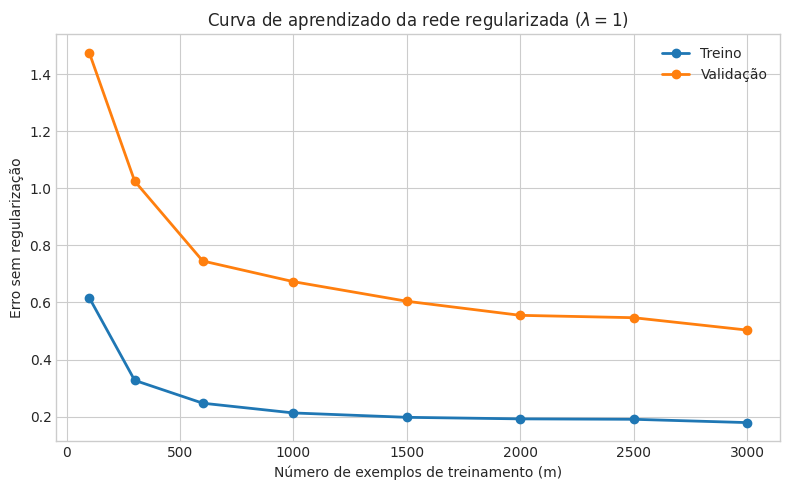

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabela_curva["m"], tabela_curva["erro treino"], "o-", lw=2, label="Treino")
ax.plot(tabela_curva["m"], tabela_curva["erro validação"], "o-", lw=2, label="Validação")
ax.set(
    xlabel="Número de exemplos de treinamento (m)",
    ylabel="Erro sem regularização",
    title=r"Curva de aprendizado da rede regularizada ($\lambda=1$)",
)
ax.legend()
plt.tight_layout()
plt.show()


### 6.1 Como interpretar a curva

Segundo as notas da disciplina:

- **alto viés:** erros de treino e validação altos e próximos;
- **alta variância:** erro de treino relativamente baixo e erro de validação bem maior;
- se o erro de validação ainda cair de forma relevante quando $m$ aumenta, mais dados podem ajudar.

A discussão final será feita a partir dos valores efetivamente obtidos, evitando diagnosticar viés ou variância apenas pela aparência de um único ponto.


## 7. Seleção automática de $\lambda$ pelo conjunto de validação

O enunciado sugere testar

$$\lambda\in\{0,0.001,0.003,0.01,0.03,0.1,0.3,1,3,10\}.$$

Para cada valor:

1. os pesos são reinicializados com a mesma semente;
2. a rede é treinada **somente** nos 3.000 exemplos de treino;
3. calculamos $J_{treino}$ e $J_{cv}$ **sem regularização**;
4. escolhemos o $\lambda$ que minimiza $J_{cv}$.

O conjunto de teste não participa desta escolha.


In [7]:
lambdas_completos = np.array([0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0])
lambdas = np.array([0.0, 0.01, 0.1, 1.0, 10.0]) if FAST_MODE else lambdas_completos.copy()

resultados_lambda = []
modelos_lambda = {}
historicos_lambda = {}

inicio_grade = perf_counter()
for lambda_reg in lambdas:
    inicio = perf_counter()
    resultado, historico = treinar_gradiente_conjugado(
        X_train, y_train, layer_sizes, classes,
        lambda_reg=float(lambda_reg),
        maxiter=MAXITER_LAMBDA,
        parametros_iniciais=theta_base,
    )
    tempo = perf_counter() - inicio

    theta = resultado.x
    modelos_lambda[float(lambda_reg)] = theta
    historicos_lambda[float(lambda_reg)] = historico

    linha = {
        "lambda": float(lambda_reg),
        "erro treino": erro_sem_regularizacao(theta, X_train, y_train, layer_sizes, classes),
        "erro validação": erro_sem_regularizacao(theta, X_val, y_val, layer_sizes, classes),
        "erro classif. treino (%)": erro_classificacao_percentual(theta, X_train, y_train, layer_sizes, classes),
        "erro classif. validação (%)": erro_classificacao_percentual(theta, X_val, y_val, layer_sizes, classes),
        "iterações": int(resultado.nit),
        "avaliações": int(resultado.nfev),
        "tempo (s)": tempo,
        "convergência declarada": bool(resultado.success),
    }
    resultados_lambda.append(linha)
    print(f"lambda={lambda_reg:g}: Jtrain={linha['erro treino']:.5f}, "
          f"Jcv={linha['erro validação']:.5f}, "
          f"erro_cv={linha['erro classif. validação (%)']:.2f}%")

tempo_grade = perf_counter() - inicio_grade
tabela_lambda = pd.DataFrame(resultados_lambda)
idx_melhor = tabela_lambda["erro validação"].idxmin()
melhor_lambda_linha = tabela_lambda.loc[idx_melhor]
lambda_otimo = float(melhor_lambda_linha["lambda"])
theta_otimo = modelos_lambda[lambda_otimo]

display(tabela_lambda.round({
    "lambda": 3,
    "erro treino": 5,
    "erro validação": 5,
    "erro classif. treino (%)": 2,
    "erro classif. validação (%)": 2,
    "tempo (s)": 2,
}))
print(f"\nLambda escolhido pela validação: {lambda_otimo:g}")
print(f"Menor erro de validação: {melhor_lambda_linha['erro validação']:.6f}")
print(f"Tempo total da grade: {tempo_grade:.2f} s")


lambda=0: Jtrain=0.00052, Jcv=1.21485, erro_cv=8.30%
lambda=0.001: Jtrain=0.00100, Jcv=1.11799, erro_cv=8.60%
lambda=0.003: Jtrain=0.00205, Jcv=0.98962, erro_cv=7.80%
lambda=0.01: Jtrain=0.00343, Jcv=0.91397, erro_cv=8.00%
lambda=0.03: Jtrain=0.00756, Jcv=0.79330, erro_cv=7.60%
lambda=0.1: Jtrain=0.02354, Jcv=0.65302, erro_cv=7.80%
lambda=0.3: Jtrain=0.06106, Jcv=0.54371, erro_cv=7.20%
lambda=1: Jtrain=0.16927, Jcv=0.49169, erro_cv=7.00%
lambda=3: Jtrain=0.33885, Jcv=0.54372, erro_cv=7.10%
lambda=10: Jtrain=0.68381, Jcv=0.76287, erro_cv=9.10%


,lambda,erro treino,erro validação,erro classif. treino (%),erro classif. validação (%),iterações,avaliações,tempo (s),convergência declarada
0,0.000,0.00052,1.21485,0.00,8.3,147,537,5.30,True
1,0.001,0.00100,1.11799,0.00,8.6,150,500,4.90,False
2,0.003,0.00205,0.98962,0.00,7.8,150,483,4.66,False
3,0.010,0.00343,0.91397,0.00,8.0,150,465,4.68,False
4,0.030,0.00756,0.79330,0.00,7.6,150,458,4.67,False
5,0.100,0.02354,0.65302,0.00,7.8,150,420,3.50,False
6,0.300,0.06106,0.54371,0.03,7.2,150,395,4.10,False
7,1.000,0.16927,0.49169,0.63,7.0,150,343,3.66,False
8,3.000,0.33885,0.54372,2.67,7.1,150,304,3.39,False
9,10.000,0.68381,0.76287,6.50,9.1,150,302,3.80,False



Lambda escolhido pela validação: 1
Menor erro de validação: 0.491690
Tempo total da grade: 42.75 s


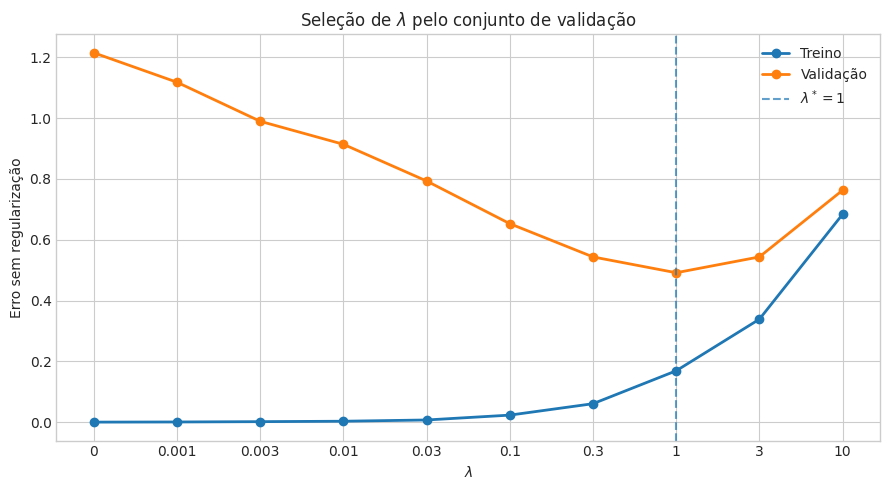

In [8]:
x = np.arange(len(tabela_lambda))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, tabela_lambda["erro treino"], "o-", lw=2, label="Treino")
ax.plot(x, tabela_lambda["erro validação"], "o-", lw=2, label="Validação")
ax.axvline(idx_melhor, ls="--", alpha=0.7, label=fr"$\lambda^*={lambda_otimo:g}$")
ax.set_xticks(x)
ax.set_xticklabels([f"{v:g}" for v in tabela_lambda["lambda"]])
ax.set(
    xlabel=r"$\lambda$",
    ylabel="Erro sem regularização",
    title=r"Seleção de $\lambda$ pelo conjunto de validação",
)
ax.legend()
plt.tight_layout()
plt.show()


## 8. Avaliação final no conjunto de teste

Somente depois de escolher $\lambda^*$ pela validação avaliamos o teste. Seguindo diretamente o procedimento das notas, usamos os mesmos parâmetros ajustados no conjunto de treino; não fazemos uma segunda escolha com base no teste.

Para cumprir também a primeira tarefa da Parte II, a tabela compara:

- a rede de referência da Parte I com $\lambda=1$;
- a rede com o $\lambda^*$ escolhido pela validação.

O conjunto de teste é usado apenas nesta etapa final e não altera $\lambda^*$.


In [9]:
# O lambda=1 faz parte da grade completa e serve como referência direta da Parte I.
if 1.0 in modelos_lambda:
    theta_lambda1 = modelos_lambda[1.0]
else:
    # Salvaguarda para grades rápidas alternativas.
    resultado_lambda1, _ = treinar_gradiente_conjugado(
        X_train, y_train, layer_sizes, classes,
        lambda_reg=1.0,
        maxiter=MAXITER_LAMBDA,
        parametros_iniciais=theta_base,
    )
    theta_lambda1 = resultado_lambda1.x


def resumo_avaliacao(nome, lambda_reg, theta):
    return {
        "modelo": nome,
        "lambda": lambda_reg,
        "J treino": erro_sem_regularizacao(theta, X_train, y_train, layer_sizes, classes),
        "J validação": erro_sem_regularizacao(theta, X_val, y_val, layer_sizes, classes),
        "J teste": erro_sem_regularizacao(theta, X_test, y_test, layer_sizes, classes),
        "erro classif. treino (%)": erro_classificacao_percentual(theta, X_train, y_train, layer_sizes, classes),
        "erro classif. validação (%)": erro_classificacao_percentual(theta, X_val, y_val, layer_sizes, classes),
        "erro classif. teste (%)": erro_classificacao_percentual(theta, X_test, y_test, layer_sizes, classes),
        "acurácia teste (%)": 100.0 - erro_classificacao_percentual(theta, X_test, y_test, layer_sizes, classes),
    }


if np.isclose(lambda_otimo, 1.0):
    tabela_final = pd.DataFrame([
        resumo_avaliacao("Referência da Parte I = selecionado", 1.0, theta_otimo),
    ])
else:
    tabela_final = pd.DataFrame([
        resumo_avaliacao("Referência da Parte I", 1.0, theta_lambda1),
        resumo_avaliacao("Selecionado por validação", lambda_otimo, theta_otimo),
    ])

display(tabela_final.round({
    "lambda": 3,
    "J treino": 5,
    "J validação": 5,
    "J teste": 5,
    "erro classif. treino (%)": 2,
    "erro classif. validação (%)": 2,
    "erro classif. teste (%)": 2,
    "acurácia teste (%)": 2,
}))


,modelo,lambda,J treino,J validação,J teste,erro classif. treino (%),erro classif. validação (%),erro classif. teste (%),acurácia teste (%)
0,Referência da Parte I = selecionado,1.0,0.16927,0.49169,0.49011,0.63,7.0,7.6,92.4


### 8.1 Erros de classificação do modelo final

Como complemento ao erro numérico $J_{teste}$, o painel abaixo mostra exemplos do conjunto de teste que foram classificados incorretamente. Isso não participa da seleção do modelo; serve apenas para inspeção qualitativa após a avaliação final.


Erros: 76 de 1000 (7.60%)


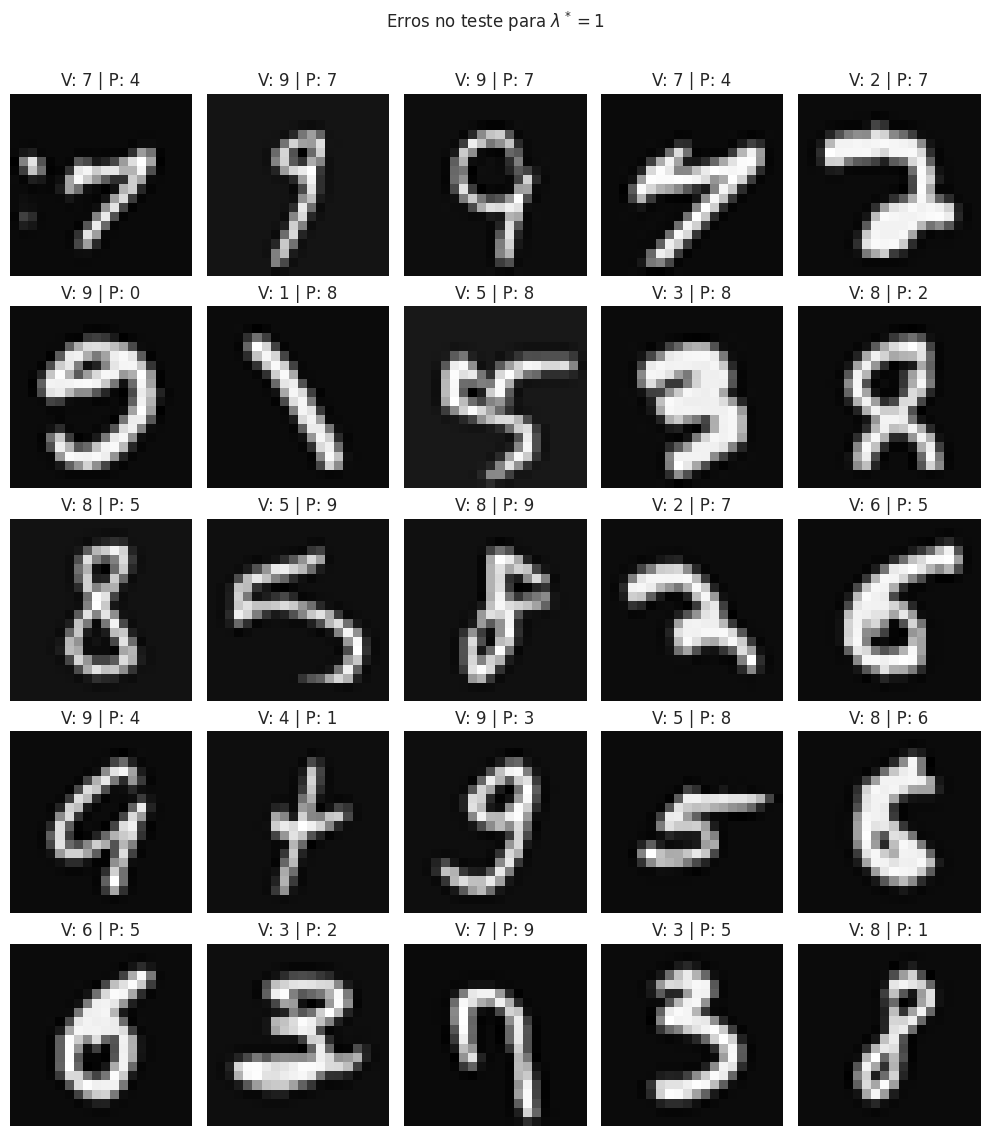

In [10]:
def mostrar_erros(X, y, pred, max_imagens=25, titulo="Erros de classificação"):
    errados = np.flatnonzero(np.asarray(y).ravel() != np.asarray(pred).ravel())
    print(f"Erros: {errados.size} de {len(y)} ({100*errados.size/len(y):.2f}%)")
    if errados.size == 0:
        print("Nenhum exemplo incorreto para mostrar.")
        return
    n = min(max_imagens, errados.size)
    colunas = 5
    linhas = int(np.ceil(n / colunas))
    fig, axes = plt.subplots(linhas, colunas, figsize=(10, 2.25 * linhas))
    axes = np.atleast_1d(axes).ravel()
    for ax, idx in zip(axes, errados[:n]):
        ax.imshow(X[idx].reshape(20, 20, order="F"), cmap="gray")
        ax.set_title(f"V: {rotulo_visual(y[idx])} | P: {rotulo_visual(pred[idx])}")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titulo, y=1.01)
    plt.tight_layout()
    plt.show()


pred_teste_otimo = predizer(theta_otimo, X_test, layer_sizes, classes)
mostrar_erros(
    X_test, y_test, pred_teste_otimo, max_imagens=25,
    titulo=fr"Erros no teste para $\lambda^*={lambda_otimo:g}$"
)


## 9. Síntese automática dos resultados

A célula abaixo reúne os principais números em texto para facilitar a redação do relatório. A interpretação deve considerar simultaneamente a curva de aprendizado, a diferença entre treino e validação e o comportamento da grade de $\lambda$.


In [11]:
linha_final = tabela_final.iloc[-1]
linha_ref = tabela_final.iloc[0]
coincide_referencia = np.isclose(lambda_otimo, 1.0)
ultimo_curva = tabela_curva.iloc[-1]
primeiro_curva = tabela_curva.iloc[0]

gap_curva_final = ultimo_curva["erro validação"] - ultimo_curva["erro treino"]
queda_validacao = primeiro_curva["erro validação"] - ultimo_curva["erro validação"]

texto = fr'''
### Resultados principais da Parte II

- A divisão estratificada produziu **{len(y_train)}** exemplos de treino, **{len(y_val)}** de validação e **{len(y_test)}** de teste.
- Na curva de aprendizado com $\lambda=1$, o erro de validação passou de **{primeiro_curva['erro validação']:.5f}** (m={int(primeiro_curva['m'])}) para **{ultimo_curva['erro validação']:.5f}** (m={int(ultimo_curva['m'])}). No maior tamanho, a diferença $J_{{cv}}-J_{{treino}}$ foi **{gap_curva_final:.5f}**.
- A seleção automática escolheu $\lambda^*={lambda_otimo:g}$ por apresentar o menor erro de validação, **{melhor_lambda_linha['erro validação']:.5f}**.
- Para o modelo selecionado, os erros sem regularização foram: $J_{{treino}}={linha_final['J treino']:.5f}$, $J_{{cv}}={linha_final['J validação']:.5f}$ e $J_{{teste}}={linha_final['J teste']:.5f}$.
- A acurácia final no conjunto de teste foi **{linha_final['acurácia teste (%)']:.2f}%**, equivalente a erro de classificação de **{linha_final['erro classif. teste (%)']:.2f}%**.
- A rede de referência com $\lambda=1$ obteve $J_{{teste}}={linha_ref['J teste']:.5f}$ e acurácia de teste **{linha_ref['acurácia teste (%)']:.2f}%**. {"Neste caso, $\lambda^*=1$ coincidiu com a configuração de referência da Parte I." if coincide_referencia else "Essa comparação é descritiva; a escolha de $\lambda$ foi feita exclusivamente pela validação."}
'''
display(Markdown(texto))



### Resultados principais da Parte II

- A divisão estratificada produziu **3000** exemplos de treino, **1000** de validação e **1000** de teste.
- Na curva de aprendizado com $\lambda=1$, o erro de validação passou de **1.47497** (m=100) para **0.50329** (m=3000). No maior tamanho, a diferença $J_{cv}-J_{treino}$ foi **0.32425**.
- A seleção automática escolheu $\lambda^*=1$ por apresentar o menor erro de validação, **0.49169**.
- Para o modelo selecionado, os erros sem regularização foram: $J_{treino}=0.16927$, $J_{cv}=0.49169$ e $J_{teste}=0.49011$.
- A acurácia final no conjunto de teste foi **92.40%**, equivalente a erro de classificação de **7.60%**.
- A rede de referência com $\lambda=1$ obteve $J_{teste}=0.49011$ e acurácia de teste **92.40%**. Neste caso, $\lambda^*=1$ coincidiu com a configuração de referência da Parte I.


## 9.1 Resultados da execução completa salva neste notebook

As tabelas a seguir resumem a execução completa com `FAST_MODE = False`, `MAXITER_CURVA = 100`, `MAXITER_LAMBDA = 150` e `SEED = 2026`. Os valores foram extraídos das mesmas tabelas geradas pelas células executadas acima. Pequenas diferenças podem ocorrer com outras versões das bibliotecas ou condições numéricas.

| $m$ | $J_{treino}$ | $J_{cv}$ | erro classif. treino | erro classif. validação |
|---:|---:|---:|---:|---:|
| 100 | 0.61643 | 1.47497 | 0.00% | 21.70% |
| 300 | 0.32712 | 1.02518 | 0.00% | 15.10% |
| 600 | 0.24704 | 0.74547 | 0.17% | 12.00% |
| 1000 | 0.21284 | 0.67294 | 0.30% | 10.60% |
| 1500 | 0.19753 | 0.60425 | 0.47% | 9.30% |
| 2000 | 0.19209 | 0.55496 | 0.65% | 7.60% |
| 2500 | 0.19063 | 0.54665 | 0.96% | 7.30% |
| 3000 | 0.17904 | 0.50329 | 0.90% | 7.10% |

Na seleção de regularização, o menor erro de validação ocorreu em **$\lambda^*=1$**:

| $\lambda$ | $J_{treino}$ | $J_{cv}$ |
|---:|---:|---:|
| 0 | 0.00052 | 1.21485 |
| 0.001 | 0.00100 | 1.11799 |
| 0.003 | 0.00205 | 0.98962 |
| 0.01 | 0.00343 | 0.91397 |
| 0.03 | 0.00756 | 0.79330 |
| 0.1 | 0.02354 | 0.65302 |
| 0.3 | 0.06106 | 0.54371 |
| 1 | 0.16927 | 0.49169 |
| 3 | 0.33885 | 0.54372 |
| 10 | 0.68381 | 0.76287 |

Para o modelo selecionado, o erro no conjunto de teste foi **$J_{teste}=0.49011$**, com **92.40% de acurácia** (7.60% de erro de classificação). O caso $\lambda=0$ produziu um erro de treino muito menor do que o erro de validação, compatível com sobreajuste. Na curva de aprendizado, o erro de validação caiu à medida que mais exemplos foram usados, mas permaneceu acima do erro de treino no maior tamanho.


## 10. Discussão crítica

A Parte II corrige a principal limitação metodológica da Parte I: a acurácia de ajuste sobre os mesmos 5.000 exemplos não era uma estimativa de generalização. Agora os papéis de cada subconjunto são separados:

1. **Treino:** determina os pesos $\Theta$ para cada valor de $\lambda$.
2. **Validação:** escolhe o hiperparâmetro $\lambda$ e permite diagnosticar a diferença entre ajuste e generalização durante o desenvolvimento.
3. **Teste:** fornece a estimativa final de desempenho depois da escolha do modelo.

A regularização aparece apenas na função minimizada durante o treinamento. Os erros usados para comparar os modelos são calculados sem a penalidade, como indicado no material didático; isso evita confundir um termo de controle de complexidade com erro preditivo.

A curva de aprendizado deve ser lida pela **distância entre as curvas** e por sua evolução com $m$. Um grande intervalo persistente entre validação e treino é compatível com maior variância; curvas altas e próximas são compatíveis com maior viés. Como a rede é não convexa e o treinamento possui limite de iterações, parte das diferenças também pode refletir otimização imperfeita. Por isso, os números da tabela e o histórico de convergência devem ser considerados junto com o gráfico.

A seleção de $\lambda$ foi feita com a grade sugerida no enunciado e a mesma inicialização em todos os casos. Isso reduz a influência da aleatoriedade na comparação. O teste não foi usado para escolher $\lambda$, evitando que o hiperparâmetro seja ajustado indiretamente ao conjunto que deveria estimar generalização.

### Limitações

- Foi usada uma única divisão estratificada e uma única semente; repetir o processo com várias sementes permitiria avaliar a variabilidade da seleção de $\lambda$.
- A arquitetura $400\rightarrow25\rightarrow10$ foi mantida fixa, pois a Parte II solicitada concentra-se na seleção de $\lambda$ e no diagnóstico por curvas de aprendizado.
- Cada ponto da curva exige um novo treinamento; por isso, o custo computacional cresce rapidamente. `FAST_MODE` existe apenas para teste técnico e não deve substituir a execução final.
- O gradiente conjugado pode encerrar por limite de iterações ou por critério numérico. Um `success=False` isoladamente não invalida o modelo, mas deve ser interpretado junto com o custo e as métricas.

## Conclusão

A Parte II implementa o protocolo completo de seleção de modelo pedido no projeto: divisão treino/validação/teste, cálculo de erros sem regularização, curva de aprendizado, busca automática de $\lambda$ por validação e avaliação final no teste. Dessa forma, a análise deixa de medir apenas capacidade de ajuste e passa a estimar a generalização da rede em exemplos que não participaram do treinamento.


## Referências

- **Notas de aula da disciplina MS571.** Capítulo 6: avaliação e seleção de modelos, escolha de $\lambda$ e curvas de aprendizado.
- **Projeto 1 - Parte II: Seleção de Modelo.** Enunciado fornecido na disciplina MS571, 2026.
- **Parte I do Projeto 1.** Notebook `Parte1_Projeto1_Redes_Neurais.ipynb`, cujas rotinas de rede neural e decisões metodológicas foram preservadas.
- NOCEDAL, J.; WRIGHT, S. J. *Numerical Optimization*. 2. ed. Springer, 2006.
